### Setting

In [11]:
import os
import sys
import numpy as np
import pandas as pd

from pathlib import Path
import pickle
import logging
import re
from tqdm.auto import tqdm
from scipy.sparse import csr_matrix, save_npz

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Raw data directory
DATA_DIR = Path('/Volumes/My Passport_2/Science-Society/data/processed')
NEWS_PATH  = DATA_DIR / "news_subject_by_year.pkl"
PAPER_PATH = DATA_DIR / "paper_subject_by_year.pkl"

# Working directory
BASE_DIR = Path('/Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc')

# Processed data directory
NETWORKS_DIR = BASE_DIR / "data" / "processed" / "networks" # Network adj matrix
EMB_DIR = BASE_DIR / "data" / "processed" / "embeddings"    # Embedding vector directory

# Result directory 
CP_DIR = BASE_DIR  / "results" / "cp_results"
PLOT_DIR = BASE_DIR  / "results" / "figures"



# Make all directory
NETWORKS_DIR.mkdir(parents=True, exist_ok=True)
EMB_DIR.mkdir(parents=True, exist_ok=True)
CP_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
YEAR_START = 1990
YEAR_END   = 2023
WINDOW     = 3

years = list(range(YEAR_START, YEAR_END + 1))

RANDOM_SEED = 42
N_RUNS = 10

### Data import

In [13]:
def normalize_subject(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = re.sub(r"\s+", " ", str(value).strip().lower())
    return text or None

def normalize_subject_table(df: pd.DataFrame, source: str) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    if "concept" in df.columns and "subject" not in df.columns:
        rename["concept"] = "subject"
    if "Date" in df.columns and "year" not in df.columns:
        rename["Date"] = "year"
    if "GOID" in df.columns and "id" not in df.columns:
        rename["GOID"] = "id"
    df = df.rename(columns=rename)

    required = {"id", "year", "subject"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{source} data missing columns {missing}; columns={list(df.columns)}")

    out = df[["id", "year", "subject"]].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["subject"] = out["subject"].map(normalize_subject)
    
    out = out.dropna(subset=["id", "year", "subject"]).drop_duplicates().reset_index(drop=True)
    out["year"] = out["year"].astype(int)
    return out

def load_subject_data(path, source, min_year, max_year) -> pd.DataFrame:
    LOGGER = logging.getLogger(__name__)
    
    with open(path, 'rb') as f:
        data = pickle.load(f)
    df = normalize_subject_table(data, source)
    df = df[(df["year"] >= min_year) & (df["year"] <= max_year)].copy()
    
    LOGGER.info("%s data: rows=%s docs=%s subjects=%s years=%s-%s", source, f"{len(df):,}", 
                f"{df['id'].nunique():,}", f"{df['subject'].nunique():,}", df["year"].min(), df["year"].max())
    return df

In [14]:
news_df  = load_subject_data(NEWS_PATH,  source="news",  min_year=YEAR_START, max_year=YEAR_END)
paper_df = load_subject_data(PAPER_PATH, source="paper", min_year=YEAR_START, max_year=YEAR_END)

### Descriptive analysis

In [15]:
def yearly_stats(df):
    docs_per_year  = df.groupby('year')['id'].nunique()
    subjs_per_year = df.groupby('year')['subject'].nunique()
    new_subjs = {}
    seen = set()
    for yr in sorted(df['year'].unique()):
        cur = set(df[df['year'] == yr]['subject'].unique())
        new_subjs[yr] = len(cur - seen)
        seen |= cur
    return docs_per_year, subjs_per_year, pd.Series(new_subjs)

news_docs, news_uniq, news_new   = yearly_stats(news_df)
paper_docs, paper_uniq, paper_new = yearly_stats(paper_df)

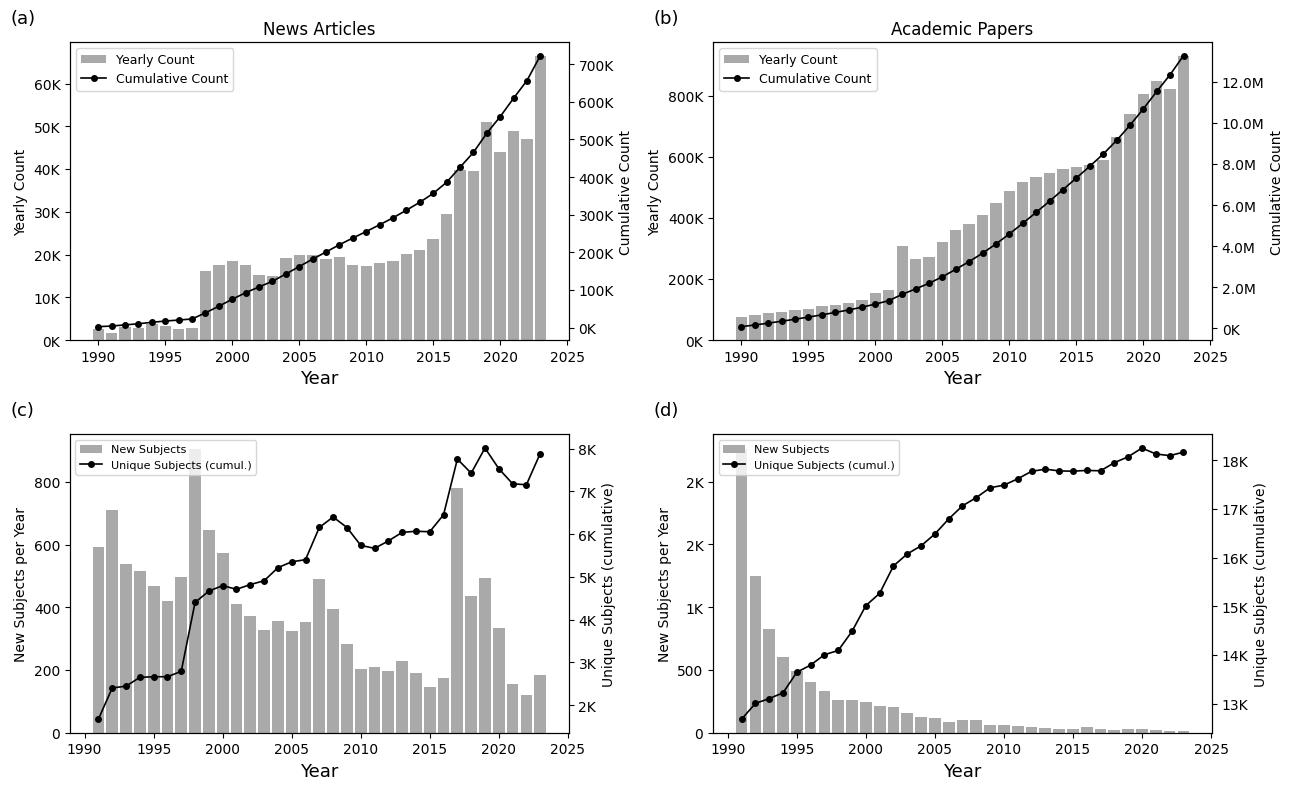

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Upper row (a, b): Yearly & cumulative documents
top_data = [
    (axes[0, 0], news_docs, 'News Articles'),
    (axes[0, 1], paper_docs, 'Academic Papers'),
]
for ax, docs, col_title in top_data:
    ax2 = ax.twinx()
    yrs = sorted(docs.index)
    vals = docs.reindex(yrs, fill_value=0)
    cumvals = vals.cumsum()
    bar = ax.bar(yrs, vals.values, color='darkgrey', width=0.85, label='Yearly Count')
    line, = ax2.plot(yrs, cumvals.values, color='black', lw=1.2, marker='o', markersize=4, label='Cumulative Count')

    ax.set_title(col_title, fontsize=12)
    ax.legend(handles=[bar, line], fontsize=9, loc='upper left', framealpha=0.8)
    ax2.set_ylabel('Cumulative Count', fontsize=10)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('Yearly Count', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))

# ── Lower row (c, d): New & cumulative unique subjects
bottom_data = [
    (axes[1, 0], news_new, news_uniq),
    (axes[1, 1], paper_new, paper_uniq),
]
for ax, new_s, uniq_s in bottom_data:
    yrs = sorted(new_s.index)[1:]  # exclude first year
    ax2 = ax.twinx()
    bar = ax.bar(yrs, new_s.reindex(yrs, fill_value=0).values,
                 color='darkgrey', width=0.85, label='New Subjects')
    line, = ax2.plot(yrs, uniq_s.reindex(yrs, fill_value=0).values,
                     color='black', lw=1.2, marker='o', markersize=4, label='Unique Subjects (cumul.)')
    ax.legend(handles=[bar, line], fontsize=8, loc='upper left', framealpha=0.8)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('New Subjects per Year', fontsize=10)
    ax2.set_ylabel('Unique Subjects (cumulative)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'))

# ── (a)(b)(c)(d) 라벨 (볼드 없음)
for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes,
            fontsize=13, fontweight='normal', va='bottom', ha='left')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'desc_combined.png', dpi=300, bbox_inches='tight')
plt.show()

### Network construction

In [21]:
def build_global_vocab(sources, output_dir):
    """
    Create the shared index space across arenas and persist it.
    sources: [("news", news_df), ("paper", paper_df)]
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    all_subjects = sorted(set().union(*(d["subject"] for _, d in sources)))
    global_subj_idx = {s: i for i, s in enumerate(all_subjects)}
    pd.Series(global_subj_idx, name="index").to_csv(output_dir / "vocab_global.csv")
    
    return global_subj_idx

def load_global_vocab(output_dir):
    s = pd.read_csv(Path(output_dir) / "vocab_global.csv", index_col=0)["index"]
    return {term: int(i) for term, i in s.items()}

def build_network(df_y, source, year, global_subj_idx, output_dir):
    """
    Build one year's raw co-occurrence matrix on the fixed global vocabulary.
    """
    
    df_y = df_y.drop_duplicates(["id", "subject"])
    d = df_y.groupby("id")["subject"].transform("size")  # unique subjects per document

    n_docs_all = df_y["id"].nunique()  # total number of documents
    n_docs_ge2 = int(d.groupby(df_y["id"]).first().ge(2).sum()) # number of documents that have more than 2 subjects
 
    w_sqrt = np.sqrt(1.0 / (d[d >= 2] - 1)).to_numpy() # sqrt so that X.T @ X yields w
    
    sub = df_y[d >= 2] # exclude documents with no edge
    col = sub["subject"].map(global_subj_idx)  # Align to the global vocabulary
    ok = col.notna().to_numpy()
    row = pd.factorize(sub["id"].to_numpy()[ok])[0] # document id to matrix index

    # Document-subject weighted matrix X
    # row = document, col = subject, value = sqrt(w), so that X.T @ X yields w
    X = csr_matrix(
        (w_sqrt[ok], (row, col.to_numpy()[ok].astype(np.int64))),
        shape=(row.max() + 1 if row.size else 0, len(global_subj_idx)),
        dtype=np.float64,
    )
    W = (X.T @ X).tocsr()
    W.setdiag(0); W.eliminate_zeros()

    save_npz(output_dir / f"{source}_fixed_adj_{year}.npz", W)

    doc_freq = np.asarray(W.sum(axis=1)).ravel()
    
    return {
        "year": year,
        "doc_freq": doc_freq,                    # document frequency per concept
        "n_docs_all": n_docs_all,                # all documents this year
        "n_docs_ge2": n_docs_ge2,                # documents that produced edges
        "V_t": int((doc_freq > 0).sum()),        # active nodes this year
        "E_t": W.nnz // 2,                       # undirected edges
    }

def build_all_years(df, source, global_subj_idx, output_dir):
    """
    Build the fixed-vocabulary network layer for one arena, all years.
    T = time (number of years), V = vocabulary (number of subjects)
    """
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stats = []
    for year, group in tqdm(df.groupby("year"), desc=source):
        stats.append(build_network(group, source, year, global_subj_idx, output_dir))

    stats.sort(key=lambda s: s["year"])
    df_year = np.stack([s["doc_freq"] for s in stats])       # [T, V]
    n_all = np.array([s["n_docs_all"] for s in stats])
    n_ge2 = np.array([s["n_docs_ge2"] for s in stats])
    doc_freq = df_year.sum(axis=0)                           # whole period

    info = {
        "vocab": [t for t, _ in sorted(global_subj_idx.items(), key=lambda x: x[1])],
        "years": np.array([s["year"] for s in stats]),

        # concept axis [V] — how common each concept is
        "concept_freq_year":  df_year,                     # [T, V] per-year count
        "concept_freq_total": doc_freq,                    # [V] summed over years
        "concept_share":      doc_freq / n_ge2.sum(),      # [V] used by the filter
        "concept_share_all":  doc_freq / n_all.sum(),      # [V] alternative denominator

        # year axis [T] — how large each year is
        "n_docs_all":       n_all,
        "n_docs_ge2":       n_ge2,
        "V_t":              np.array([s["V_t"] for s in stats]),
        "E_t":              np.array([s["E_t"] for s in stats]),
    }

    with open(output_dir / f"{source}_node_info.pkl", "wb") as f:
        pickle.dump(info, f)
    return info

In [18]:
# Build the shared index space once, from both arenas
global_subj_idx = build_global_vocab(
    [("news", news_df), ("paper", paper_df)], NETWORKS_DIR
)
print(f"vocab: {len(global_subj_idx):,}")

vocab: 34,403


In [19]:
# Build each arena independently on that shared vocabulary
info_news  = build_all_years(news_df,  "news",  global_subj_idx, NETWORKS_DIR)
info_paper = build_all_years(paper_df, "paper", global_subj_idx, NETWORKS_DIR)

news:   0%|          | 0/34 [00:00<?, ?it/s]

paper:   0%|          | 0/34 [00:00<?, ?it/s]

In [20]:
# Summary
for source, info in [("news", info_news), ("paper", info_paper)]:
    ratio = info["n_docs_ge2"].sum() / info["n_docs_all"].sum()
    print(f"{source}: {len(info['years'])} years | "
          f"docs {info['n_docs_all'].sum():,} | d>=2 {ratio:.3f} | "
          f"V_t {info['V_t'][0]:,}->{info['V_t'][-1]:,} | "
          f"E_t {info['E_t'][0]:,}->{info['E_t'][-1]:,}")

news: 34 years | docs 722,889 | d>=2 0.965 | V_t 2,434->7,883 | E_t 43,851->445,010
paper: 34 years | docs 13,288,831 | d>=2 0.949 | V_t 12,593->18,159 | E_t 397,239->2,009,733
